In [1]:
from pathlib import Path

from config import PLOTS_DIR
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

In [43]:
from core.dgp import DGP_EXAMPLES, ARProcess, GARCHProcess, ARGARCHProcess
from core.sr_study_analysis import set_extra_dgps

DGP_EXAMPLES["ar1_normal_"] = lambda phi: ARProcess(phi=phi)
DGP_EXAMPLES["garch_"] = lambda _alpha, beta: GARCHProcess(alpha=_alpha, beta=beta)



## Scenarios and parameter grids

In [44]:
# name : (dgp_names, model_short_names)
scenarios = {
    "a_plus_b": (
        ["garch_"],
        ["garch11"],
    ),
    "phi": (
        ["ar1_normal_"],
        ["ar1_normal"],
    ),
    "sr": (
        ["iid_normal"],
        ["iid_normal", "iid_nonnormal", "ar1_normal"],
    ),
    "non4": (
        ["iid_t3", "iid_t6"],
        ["iid_student_t"],
    ),
    "efficiency": (
        ["iid_normal"],
        ["iid_normal", "iid_student_t", "iid_nonnormal", "ar1_normal", "ar1_nonnormal"],
    ),
}

parameters = {
    "sr":    [0.5, 0.7, 1.0, 1.2, 1.5, 1.8, 2.0],
    "T":     [100, 500, 2_000],
    "n_sim": [1_000, 10_000, 50_000],
}

## Experiment registry

In [69]:
c = 0.1
[(round(sum*c, 3), round(sum*(1-c),3)) for sum in [0.7, 0.8, 0.9, 0.92, 0.95, 0.98]]

[(0.07, 0.63),
 (0.08, 0.72),
 (0.09, 0.81),
 (0.092, 0.828),
 (0.095, 0.855),
 (0.098, 0.882)]

In [70]:
N_SIM  = 30_000
N_JOBS = 8

experiments = {
    "a_plus_b": ExperimentSpec(
        scenario   = scenarios["a_plus_b"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        T_default=100,
        n_default=30_000,
        sr_default=0.5,
        n_jobs = N_JOBS,
        th_moments = True,
        label_param  = ("_alpha", "beta"),
        label_values = [(0.07,0.63),(0.08, 0.72),(0.09,0.81),(0.092, 0.828),(0.095, 0.855),(0.098,0.882)],
    ),
    "phi": ExperimentSpec(
        scenario   = scenarios["phi"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        T_default=100,
        n_default=30_000,
        sr_default=0.5,
        n_jobs = N_JOBS,
        label_param  = "phi",
        label_values = [-0.6, -0.4, -0.2, 0.2, 0.4, 0.6],
    ),
    "sr": ExperimentSpec(
        scenario   = scenarios["sr"],
        param_name = "sr",
        param_values = parameters["sr"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        T_default=100,
        n_default=50_000,
        n_jobs = N_JOBS,
    ),
    "non4": ExperimentSpec(
        scenario   = scenarios["non4"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "efficiency": ExperimentSpec(
        scenario   = scenarios["efficiency"],
        # param_name = "n_sim",
        # param_values = [100, 1000, 5000, 10_000, 50_000],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        T_default=50,
        #n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
}

---
## EXECUTION

In [71]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        "a_plus_b",
        #"phi",
        #"sr",
        #"non4",
        #"efficiency",
    ],
)


  Experiment: a_plus_b
  [1/18]  T=100  ('_alpha', 'beta')=(0.07, 0.63)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [2/18]  T=500  ('_alpha', 'beta')=(0.07, 0.63)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [3/18]  T=2000  ('_alpha', 'beta')=(0.07, 0.63)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [4/18]  T=100  ('_alpha', 'beta')=(0.08, 0.72)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [5/18]  T=500  ('_alpha', 'beta')=(0.08, 0.72)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [6/18]  T=2000  ('_alpha', 'beta')=(0.08, 0.72)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [7/18]  T=100  ('_alpha', 'beta')=(0.09, 0.81)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [8/18]

---
## VISUALIZATION

In [72]:
#common
import numpy as np
import matplotlib.pyplot as plt

line_plot_kargs = dict(reverse=False, 
                       linewidth=1,)
folder = PLOTS_DIR / "scenarios_add"

In [73]:
colors = [
    "#e7d4d8",
    "#d9b3bc",
    "#c08a9b",
    "#9f6a8b",
    "#7e4f7a",
    "#5b3a66"
]

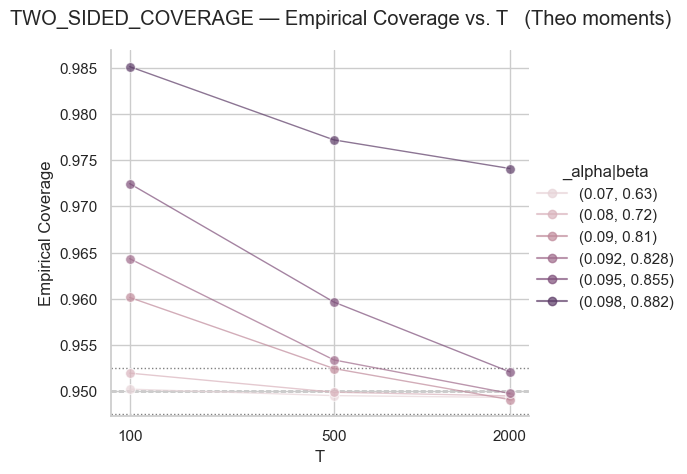

In [74]:
# palette=list(plt.cm.RdPu(np.linspace(0.4, 1, 5)))
run_analysis(experiments, "a_plus_b", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=parameters['T'], palette=colors
                  ))

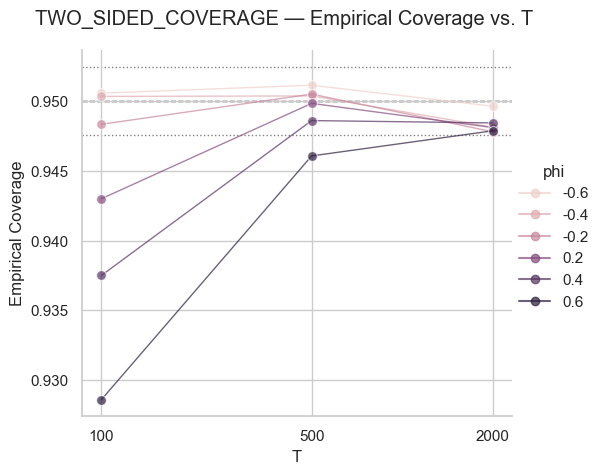

In [36]:
run_analysis(experiments, "phi", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=parameters['T']))

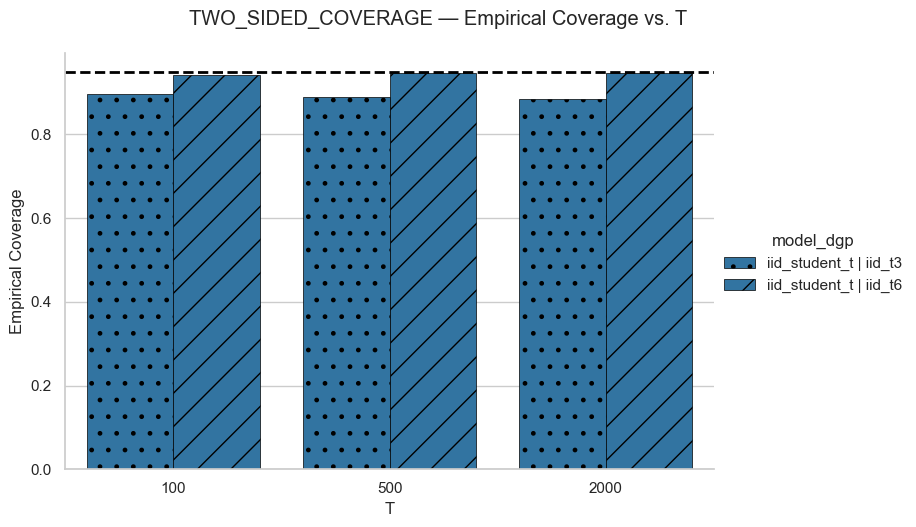

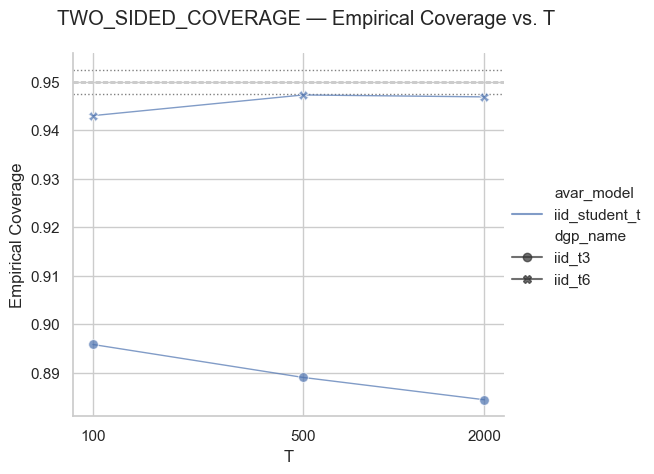

In [ ]:
run_analysis(experiments, "non4", alpha=0.05, plot_mask=[0,1,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, markers=['o', 'X'], xticks=parameters['T']))

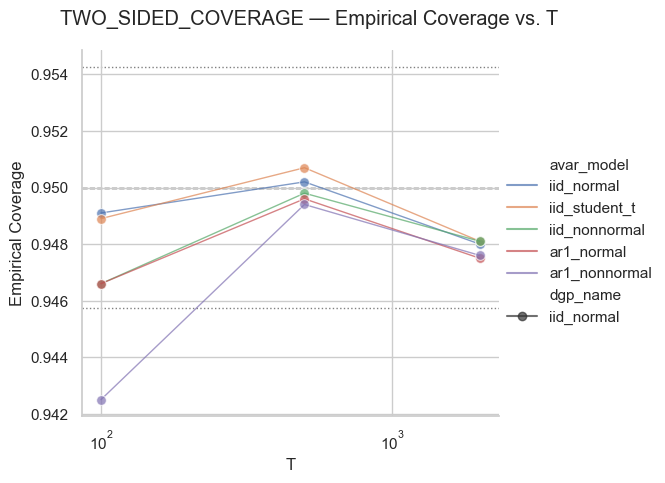

In [15]:
run_analysis(experiments, "efficiency", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True))

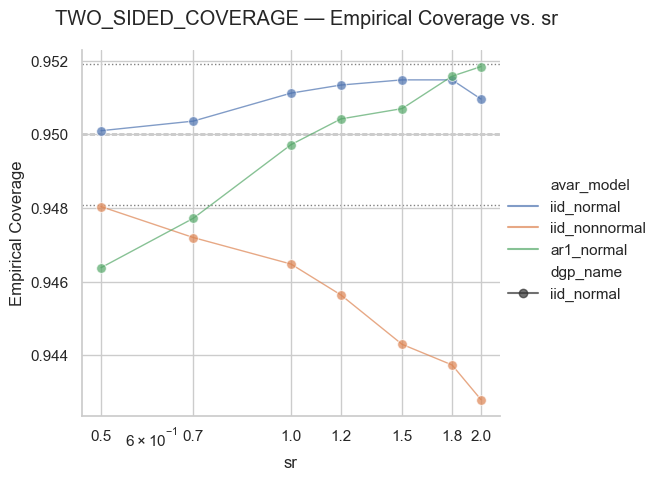

In [31]:
run_analysis(experiments, "sr", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=parameters['sr']))